In [4]:
import numpy as np
import pandas as pd
import seaborn as sns


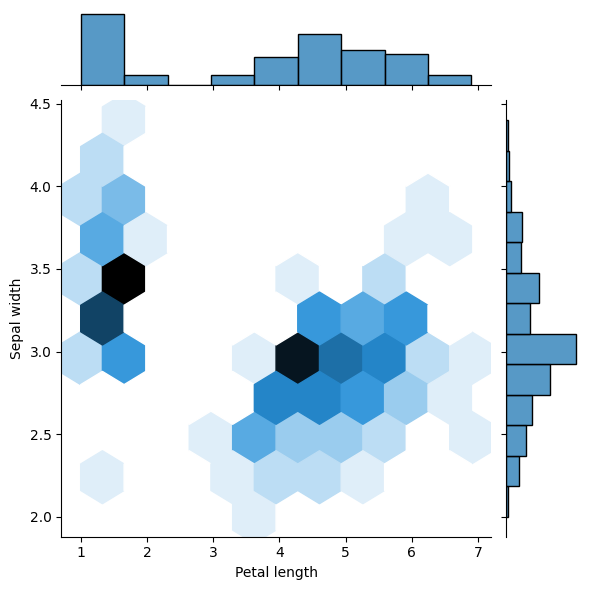

In [15]:
iris_data = pd.read_csv('iris.data')
column_names = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Class']
iris_data.columns = column_names
iris_data.head()
fig1 = sns.jointplot(x='Petal length', y='Sepal width',kind='hex', data=iris_data)



In [6]:
features = iris_data.iloc[:, 0:4]
label = iris_data.iloc[:, 4]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=0)
print('Number of train data' ,X_train.shape[0])
print('Number of data test', y_test.shape[0])

Number of train data 119
Number of data test 30


In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5,
weights="distance")
knn.fit(X_train, y_train)
train_acc = knn.score(X_train, y_train)
print("The accuracy Of KNN classifier on training data is : {:.3f}".format(train_acc))

The accuracy Of KNN classifier on training data is : 1.000


In [8]:
from subprocess import check_output
from sklearn import tree
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [9]:
data = pd.read_csv('iris.data')
features = data.iloc[:, 0:4]
label= data.iloc[:, 4]

Text(0.5, 1.0, 'Confusion Matrix')

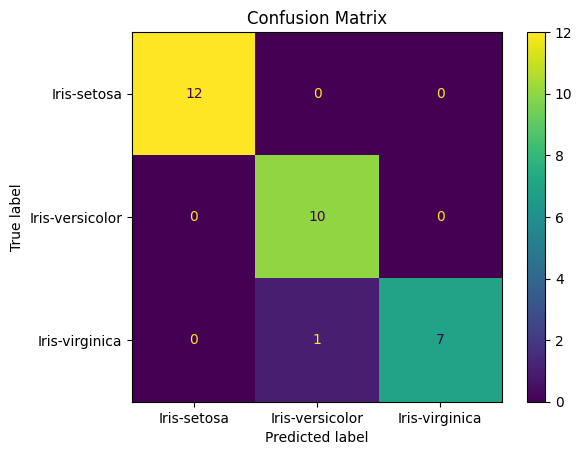

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(knn ,X_test,y_test)
disp.ax_.set_title('Confusion Matrix')

In [11]:
from sklearn.neighbors import KNeighborsClassifier
n_range = list(range(1,10))
weight_list = ['uniform','distance']
param_grid = {'n_neighbors': n_range, 'weights':weight_list}
grid = GridSearchCV(estimator = KNeighborsClassifier(),

param_grid = param_grid,
cv = 3,
scoring = 'accuracy',
refit = True)

knn_model = make_pipeline(preprocessing.StandardScaler(),
grid)
knn_model.fit(features, label)
print("Accuracy of the tuned model: %.4f" %grid.best_score_)
print(grid.best_params_)

Accuracy of the tuned model: 0.9665
{'n_neighbors': 6, 'weights': 'distance'}


In [16]:
import pickle
with open('knn_model.pickle', 'wb') as f:
    pickle.dump(knn_model, f)

In [21]:
with open('knn_model.pickle', 'rb') as f:
    model = pickle.load(f)
# Predict new data
new_data =[6.5, 3.5, 5.5, 2.0]
X= np.array([new_data])
prediction = model.predict(X)
print("Prediction of Species: {}".format(prediction))

Prediction of Species: ['Iris-virginica']


C:\Users\fayje_3xvy5tx\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
